# Assignment 1

**Assignment 1: Optimization**

**Goal**: ​Get familiar with gradient-based and derivative-free optimization by implementing these methods and applying them to a given function.

**Note**: All assignments are individual, group work and/or the use of generative AI tools for completing the assignments in any capacity and/or copy paste from any resource are considered as plagiarism and reported.

In this assignment we are going to learn about **gradient-based** (GD) optimization methods and **derivative-free optimization** (DFO) methods. The goal is to implement these methods (one from each group) and analyze their behavior. Importantly, we aim at noticing differences between these two groups of methods.

Here, we are interested in ​minimizing​ the following function:

$$
f(\mathbf{x})=x_{1}^{2}+2 x_{2}^{2}-0.3 \cos \left(3 \pi x_{1}\right)-0.4 \cos \left(4 \pi x_{2}\right)+0.7
$$

in the domain $\mathbf{x} = (x_1, x_2) \in [-100, 100]^{2}$ (i.e., $x_1 \in [-100, 100]$, $x_2 \in [-100, 100]$).

In this assignemnt, you are asked to implement:
1. The gradient-descent algorithm.
2. A chosen derivative-free algorithm. *You are free to choose a method.*

After implementing both methods, please run experiments and compare both methods. Please find a more detailed description below.

## 1. Understanding the objective

Please run the code below and visualize the objective function. Please try to understand the objective function, what is the optimum (you can do it by inspecting the plot).

If any code line is unclear to you, please read on that in numpy or matplotlib docs.

In [180]:
import matplotlib.pyplot as plt
import numpy as np

In [181]:
# PLEASE DO NOT REMOVE!
# The objective function.
def f(x):
    return (
        x[:, 0] ** 2
        + 2 * x[:, 1] ** 2
        - 0.3 * np.cos(3.0 * np.pi * x[:, 0])
        - 0.4 * np.cos(4.0 * np.pi * x[:, 1])
        + 0.7
    )

In [182]:
# PLEASE DO NOT REMOVE!
# Calculating the objective for visualization.
def calculate_f(x1, x2):
    f_x = []
    for i in range(len(x1)):
        for j in range(len(x2)):
            f_x.append(f(np.asarray([[x1[i], x2[j]]])))

    return np.asarray(f_x).reshape(len(x1), len(x2))

In [183]:
# PLEASE DO NOT REMOVE!
# Define coordinates
x1 = np.linspace(-100.0, 100.0, 400)
x2 = np.linspace(-100.0, 100.0, 400)

# Calculate the objective
f_x = calculate_f(x1, x2).reshape(len(x1), len(x2))

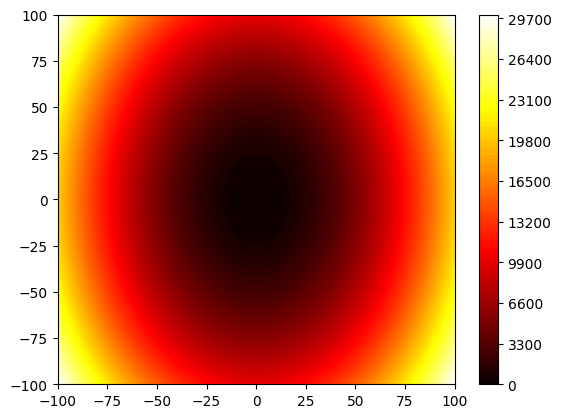

In [184]:
# PLEASE DO NOT REMOVE!
# Plot the objective
plt.contourf(x1, x2, f_x, 100, cmap="hot")
plt.colorbar()

## 2. The gradient-descent algorithm

First, you are asked to implement the gradient descent (GD) algorithm. Please take a look at the class below and fill in the missing parts.

NOTE: Please pay attention to the inputs and outputs of each function.

NOTE: To implement the GD algorithm, we need a gradient with respect to $\mathbf{x}$ of the given function. Please calculate it on a paper and provide the solution below. Then, implement it in an appropriate function that will be further passed to the GD class.

**Question 1 (0-1pt):** What is the gradient of the function $f(\mathbf{x})$? Please fill below both the mathematical expression and within the code.

**Answer:**
\begin{align*}
\nabla_{\mathbf{x}_1} f(\mathbf{x}) &= 2x_{1}+0.3 \sin(3\pi x_{1}) * 3 \pi  \textbf{ (0.15 pt)}\\
\nabla_{\mathbf{x}_2} f(\mathbf{x}) &= 4x_{2}+0.4 \sin(4\pi x_{2}) * 4 \pi \textbf{ (0.15 pt)}\\
\end{align*}

$$
f(\mathbf{x})=x_{1}^{2}+2 x_{2}^{2}-0.3 \cos \left(3 \pi x_{1}\right)-0.4 \cos \left(4 \pi x_{2}\right)+0.7
$$

In [185]:
# =========
# GRADING:
# 0
# 0.5pt - if properly implemented and commented well
# =========
# Implement the gradient for the considered f(x).
def grad(x):
    '''
    Calculating the gradient for the given function f(x)
    '''
    # PLEASE FILL IN:
    grad = np.column_stack((2 * x[:, 0] + 0.9 * np.pi * np.sin(3 * np.pi * x[:, 0]),       # column_stack for later multiplication and substraction
                            4 * x[:, 1] + 1.6 * np.pi * np.sin(4 * np.pi * x[:, 1])))      # 0.7 pt

    return grad

In [186]:
# =========
# GRADING:
# 0
# 0.5pt if properly implemented and commented well
# =========
# Implement the gradient descent (GD) optimization algorithm.
# It is equivalent to implementing the step function.
class GradientDescent(object):
    def __init__(self, grad, step_size=0.1):
        self.grad = grad
        self.step_size = step_size

    def step(self, x_old):
        ''' 
        Formula based calculation of a new point: we are descending towards anti-gradient
        '''
        # PLEASE FILL IN:
        x_new = x_old - np.asarray(self.step_size) * self.grad(x_old)  # 0.7pt 
        # ------
        return x_new

In [187]:
# PLEASE DO NOT REMOVE!
# An auxiliary function for plotting.
def plot_optimization_process(ax, optimizer, title):
    # Plot the objective function
    ax.contourf(x1, x2, f_x, 100, cmap="hot")

    # Init the solution
    x = np.asarray([[90.0, -90.0]])
    x_opt = x
    # Run the optimization algorithm
    for i in range(num_epochs):
        x = optimizer.step(x)
        x_opt = np.concatenate((x_opt, x), 0)

    ax.plot(x_opt[:, 0], x_opt[:, 1], linewidth=3.0)
    ax.set_title(title)

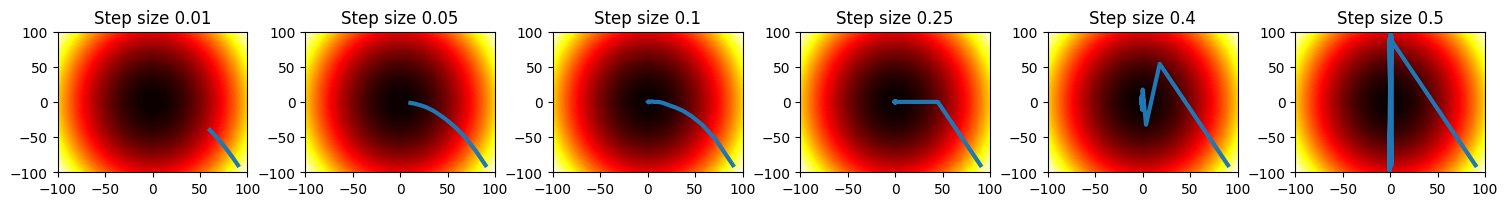

In [188]:
# PLEASE DO NOT REMOVE!
# This piece of code serves for the analysis.
# Running the GD algorithm with different step sizes
num_epochs = 20  # the number of epochs
step_sizes = [0.01, 0.05, 0.1, 0.25, 0.4, 0.5]  # the step sizes

# plotting the convergence of the GD
fig_gd, axs = plt.subplots(1, len(step_sizes), figsize=(15, 2))
fig_gd.tight_layout()

for i in range(len(step_sizes)):
    # take the step size
    step_size = step_sizes[i]
    # init the GD
    gd = GradientDescent(grad, step_size=step_size)
    # plot the convergence
    plot_optimization_process(
        axs[i], optimizer=gd, title="Step size " + str(gd.step_size)
    )

**Question 2 (0-0.5pt)**: Please analyze the plots above and comment on the behavior of the gradient-descent for different values of the step size. What happens in the small and large step sizes and what is the optimum step size?

**Answer**: If a step size is inappropriate, then the optimum not be reached. In case of a smaller step GD stops before reaching the optimum, in case of a larger one it jumps around the optimum (jumps in right direction but over the optimum). Down there you may find the code that uncovers the point reached after the last step. As one might see, the best step sizes are actually `.1` and `.25` and probably `.4`: the GD with these step size parameters ended nearly close to the optimum.

In [189]:
num_epochs = 20  # the number of epochs
step_sizes = [0.01, 0.05, 0.1, 0.25, 0.4, 0.5]  # the step sizes
last_points = []

for i in range(len(step_sizes)):
    # take the step size
    step_size = step_sizes[i]
    # inititialization of the GD
    gd = GradientDescent(grad, step_size=step_size)
    x = np.asarray([[90.0, -90.0]])
    x_opt = x

    # GD process
    for i in range(num_epochs):
        x = gd.step(x)
        x_opt = np.concatenate((x_opt, x), 0)

    # saving the last point for the analysis
    last_points.append(x_opt[-1])

for step_size, last_point in zip(step_sizes, last_points):
    print('step size: ', step_size, 'last point: ', last_point, 'distance to the minimum: ', np.linalg.norm(last_point - np.asarray([[0.0, 0.0]])), '')

step size:  0.01 last point:  [ 60.16770604 -39.85386416] distance to the minimum:  72.16982290793736 
step size:  0.05 last point:  [10.80846873 -1.41565721] distance to the minimum:  10.900783527857246 
step size:  0.1 last point:  [0.52823446 0.15368666] distance to the minimum:  0.5501374673805792 
step size:  0.25 last point:  [-0.19523705 -0.5980129 ] distance to the minimum:  0.629076255228583 
step size:  0.4 last point:  [-0.72984055 -0.6853502 ] distance to the minimum:  1.0011853567525786 
step size:  0.5 last point:  [ -0.39354102 -99.47349024] distance to the minimum:  99.47426870519605 



**Question 3 (0-0.5pt)**: How can we improve the convergence when the step size equals 0.01? What about when the step size equals 0.5?

**Answer**: In case of a step size of `.01` we may increase the number of epochs (so, with more done steps GD will get closer to the optimum). A step size of `.5` is large, so we could try to decrease the number of epochs or make the step size dynamic (that is, we start with a step size of `.5` and gradually decrease it by `.05` after each step). Moreover, we can notice that on the last steps the trace bounces from side to side passing through the optimum point (0, 0). Thus, we could take the coordinates not of the last point but rather of the average of two last points (i.e. center point between two last points).

## 3. The derivative-free optimization

In the second part of this assignment, you are asked to implement a derivative-free optimziation (DFO) algorithm. Please notice that you are free to choose any DFO method you wish.
Moreover, you are encouraged to be as imaginative as possible! Do you have an idea for a new method or combine multiple methods? Great!

**Question 4 (0-0.5-1-1.5-2-2.5-3pt)**: Please provide a description (a pseudocode) of your DFO method here.

*NOTE (grading): Please keep in mind: start simple, make sure your approach works. You are encouraged to use your creativity and develop more complex approaches that will influence the grading. TAs will also check whether the pseudocode is correct.*

**Answer:** I've implemented a hill clibming algorythm with a dynamic step size depending on hyperparameter $\eta$ and step number $t$. A new point is being calculated as a point with minimal value among $R$ points uniformly distributed on a circumference with a radius $r$ from the center $-$ previous point:


So, here goes a formula for every new point $\mathbf{x}_{new}$:

$$
\mathbf{x}_{new} = \arg\min_{\mathbf{p} \in P} f(\mathbf{p})
$$

where $P$ is a set of $R$ points uniformly distributed on a circumference with a radius $r$ from the previous point:

$$
P = \left\{ 
\mathbf{x}_{old} + r \begin{pmatrix} 
\cos\left(\frac{2\pi k}{R}\right) \\ 
\sin\left(\frac{2\pi k}{R}\right) 
\end{pmatrix} 
\mid k = 0, 1, \dots, R-1 
\right\}
$$

Parameter $R$ is calculated on every step s.t. on the later steps there are more points generated (this enables doing more meticulous steps at the end):

$$
R = 20 \cdot \left\lfloor \sqrt{n} \right\rfloor
$$

Parameter $r$ depends on two hyperparameters: $\eta $ (`decay parameter`) and $s$ (`step size`) $-$ and on the step number:

$$
r = \frac{s}{n^{\eta}}
$$

It basically means that the larger step size is, the further every next point will be located. However, we do have the decay hyperparameter $\eta$ which controls the rate of radius reduction. On every step it reduces the step size: with a smaller $\eta$ radius decreases slower, with a larger $\eta$ radius decreases faster.

*Input:* 
- `x_old` $-$ a point of the previous step
- `step_size` $-$ hyperparameter responsible for the search speed
- `eta` $-$ hyperparameter controlling the decay of the step size

*Steps:*
1. Calculating a new distance $r$ based on hyperparameters and step number.
2. Calculating $R$ new points at distance $r$ from the old point. 
3. Finding the one point among new ones with the least value for the given function.
4. Retreive new point `x_new`

In [190]:
# =========
# GRADING: 0-0.5-1-1.5-2pt
# 0
# 0.5pt the code works but it is very messy and unclear
# 1.0pt the code works but it is messy and badly commented
# 1.5pt the code works but it is hard to follow in some places
# 2.0pt the code works and it is fully understandable
# =========
# Implement a derivative-free optimization (DFO) algorithm.
# REMARK: during the init, you are supposed to pass the obj_fun and other objects that are necessary in your method.
class DFO(object):
    def __init__(self, obj_fun=f, step_size=0.5, eta=0.3):
        self.obj_fun = obj_fun
        self.step_size = step_size # hyperparameter: initial step size
        self.step_number = 1  # counter for the number of steps taken
        self.eta = eta  # decay hyperparameter for the step size


    ## PLEASE FILL IN IF NECESSARY
    ## Please remember that for the DFO you may need extra functions.
    def circumference_points(self, x_old):
        '''
        This function generates points on the circumference of a circle centered at x_old with a radius that depends on the step size and the step number.
        '''
        # how many points to generate
        num_points = 20 * int(np.floor(self.step_number ** 0.5))

        # generating angles from 0 to 2*pi (evenly spaced)
        angles = np.linspace(0, 2 * np.pi, num_points, endpoint=False)
        # calculating the radius of the circle based on the step size and the step number
        r = self.step_size / self.step_number ** self.eta
        
        # coordinates of the new points
        x = x_old[:, 0] + r * np.cos(angles)
        y = x_old[:, 1] + r * np.sin(angles)
        
        # making pairs of (x, y) coordinates for the new points
        return np.stack((x, y), axis=-1)
    

    # This function MUST be implemented.
    # No additional arguments here!
    def step(self, x_old):
        ## PLEASE FILL IN.
        lower_points = self.circumference_points(x_old)  # getting the new points

        # here we are calculating the objective function values for the new points and finding the one with the minimum value to move towards it
        obj_values = np.array([self.obj_fun(np.array([[p[0], p[1]]])) for p in lower_points])
        min_idx = np.argmin(obj_values)
        x_new = lower_points[min_idx]

        # counter plus one
        self.step_number += 1
        return np.array([x_new])

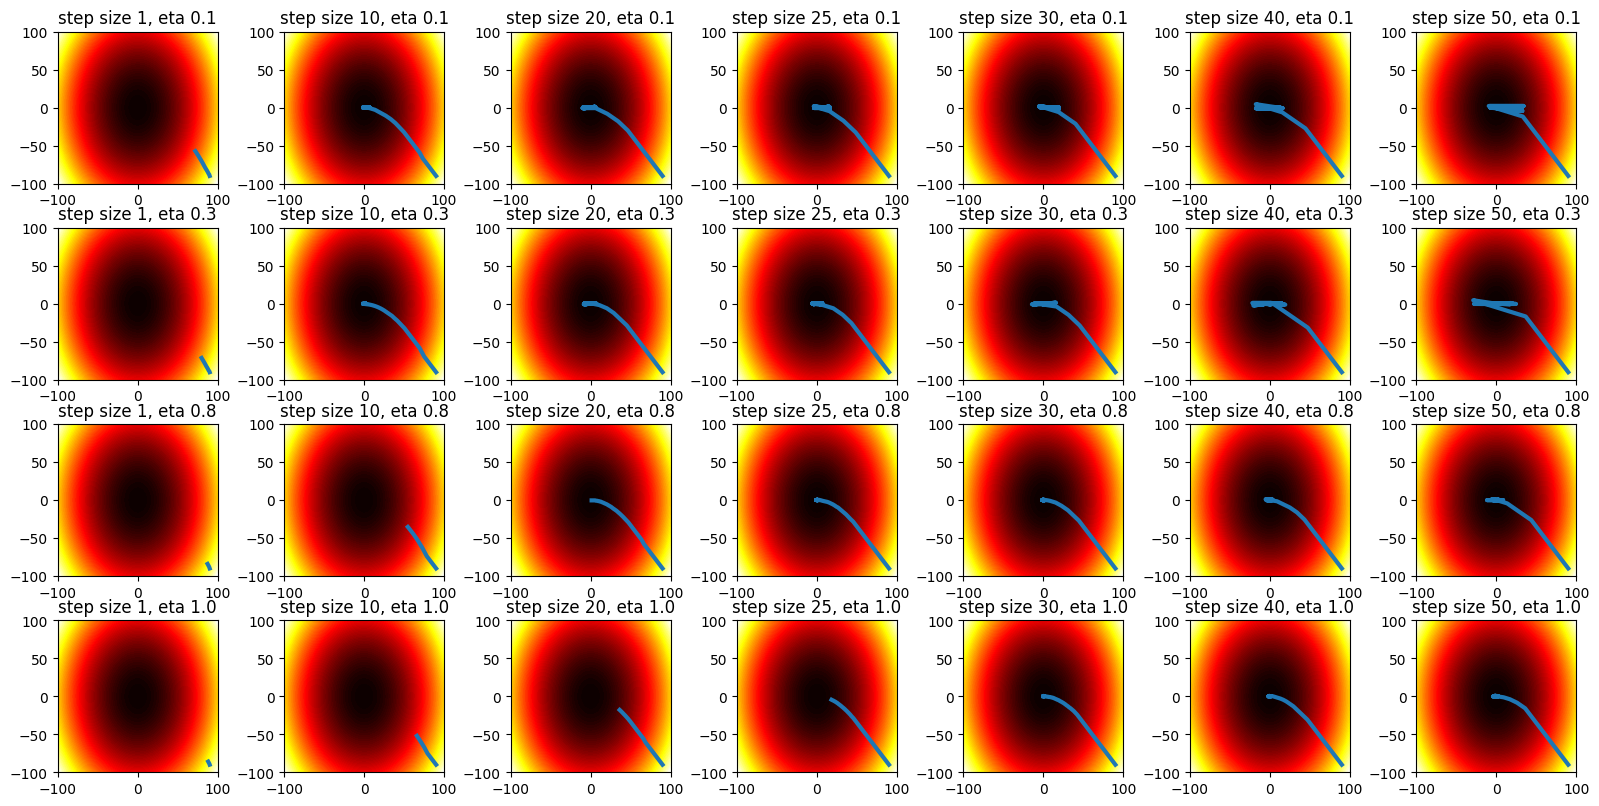

In [191]:
# PLEASE DO NOT REMOVE!
# Running the DFO algorithm with different step sizes
num_epochs = 50  # the number of epochs (you may change it!)

# PLEASE FILL IN
# Here all hyperparameters go.
# Please analyze at least one hyperparameter in a similar manner to the
# step size in the GD algorithm.

# we are going to eplxore two hyperparameters
hyperparameters = {'step_sizes': [1, 10, 20, 25, 30, 40, 50],
                   'eta': [0.1, 0.3, 0.8, 1.0]}


# plotting the convergence of the DFO
# Please uncomment the two lines below, but please provide the number of axes (replace HERE appriopriately)
fig_dfo, axs = plt.subplots(4, len(hyperparameters['step_sizes']), figsize=(16, 8))
fig_dfo.tight_layout()

# the for-loop should go over (at least one) parameter(s) (replace HERE appriopriately)
# and uncomment the line below
for i in range(len(hyperparameters['step_sizes'])):
    for eta in hyperparameters['eta']:
        # take the step size
        step_size = hyperparameters['step_sizes'][i]
        # init the DFO
        dfo = DFO(obj_fun=f, step_size=step_size, eta=eta)
        # plot the convergence
        plot_optimization_process(
            axs[hyperparameters['eta'].index(eta), i], optimizer=dfo, title='step size ' + str(dfo.step_size) + ', eta ' + str(dfo.eta)
        )

**Question 5 (0-0.5-1pt)** Please comment on the behavior of your DFO algorithm. What are the strong points? What are the (potential) weak points? During working on the algorithm, what kind of problems did you encounter?

**Answer:** As one might see, some of the combinations of `step size` & $\eta$ has resulted quite in the optimum. Moreover, the influence of the $\eta$ seems to be crystall clear and is acting pretty the same way as it we've predicted initially. So, I think that such pairs as (10, 0.3), (20, 0.8), (25, 0.8), (30, 0.8), (40, 0.8), (30, 1.), (40, 1.), and (50, 1.) gave perfect or almost perfect result.  
One of the strongest points is the number of controlled parameters which could influence the result. In our case, we explored and thus indeed had a control over just two of them: step size and decay parameter. However, there are more of them: parameters in the formula for calculation number of new points, nature of the distribution of these new points around an old one and some others. The dynamic alteration of the radius for each following point enables a controlled decay of the searching algorythm. Overall, if we had a more complex landscape of objective function, these techniques would probably help avoiding local minima and finding the global optimum (especially, with a cross validation for finding the best fitting hyperparameters).  
The apparent weak point is that DFO seems to require more calculations, thus the process is computationally complex. And if we consider more multidimensional landscape, the computational complexity will increase significantly compared to basic GD.  
The most irritating problem for me was to control the dimensions of the points ¯\\\_(ツ)_/¯ (I suffered). Another difficulty I've encountered was implementing the right algorythm for calculation of the new points on a circumference with a center at the given point (I'm  pretty sure that there is an easier way to generate those dots).

## 4. Final remarks: GD vs. DFO

Eventually, please answer the following last question that will allow you to conclude the assignment draw conclusions.

**Question 6 (0-0.5pt)**: What are differences between the two approaches?

**Answer**: Gradient descent uses the knowledge about nature of the function given (derivative of that function), while DFO does not require this special knowledge. GD would work better with more multidimensional landskapes and require overall less calculation (in this sense we could say that it's more precise). However, DFO with some modifications could withstand some irregularities (for example, flat regions where gradient equals zero). (My implementation of DFO won't handle this problem though.) 

**Question 7 (0-0.5)**: Which of the is easier to apply? Why? In what situations? Which of them is easier to implement in general?

**Answer**: To my mind, gradient descent algorythm (and especially its varieties) is easier to apply because of the mathematical precision and universality. By that, I imply that $-$ comparing solely these two implemented optimization functions $-$ there is no need to select and control too many hyperparameters and parameters in the GD approach. So, I think that GD is an overall preferable approach (particularly if we consider modifications of gradient descent). However, if the function is not differential, that might be challenging for GD algorythm (in fact it simply won't work if the function is discrete or nondifferentiable). That's why DFO may be still be the choice depending on the characteristics of the objective function.